# Lab 3 — Before/After Redesign
### SDA-DSC-112 · Module 3 · Colour, Annotation, and Decluttering · **50 minutes**

| | |
|---|---|
| **Objective** | Take a deliberately cluttered, mis-coloured Tayseer chart and redesign it: correct palette, decluttered, annotated with the takeaway, colour-blind-safe, and shipped in Arabic — then measure the improvement |
| **Dataset** | `tayseer_services.csv` · `brand_palette.csv` · `dim_regions.csv` (Arabic names) · `dim_calendar.csv` (Arabic months) |
| **Output** | A genuine before/after pair, a CVD simulation, an Arabic RTL edition, and a data-ink count |

| Task | Minutes |
|---|---|
| 1 · Study the cluttered chart and list every violation | 5 |
| 2 · Rebuild with the correct palette type | 10 |
| 3 · Apply the decluttering ladder | 10 |
| 4 · Annotate: takeaway title + exactly one callout | 10 |
| 5 · Colour-blind simulation, and the redundant cue | 5 |
| 6 · The Arabic RTL edition | 5 |
| 7 · Measure it: data-ink before vs after | 5 |

### Setup

The subject is **cost per transaction by region, latest month** — a measure with a
*meaningful midpoint* (the 18 SAR programme target). Remember which weight it takes:
`SUM(cost × transactions) / SUM(transactions)`, never `AVERAGE(cost)`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import tayseer_viz as tv
tv.apply_theme()

df = tv.load_facts()
regions = tv.load("dim_regions.csv")
calendar = tv.load("dim_calendar.csv", parse_dates=["month"])
brand = tv.load("brand_palette.csv")

latest = df[df.month == df.month.max()]
cost = (tv.by(latest, "region", "cost_per_txn_sar")
          .rename(columns={"cost_per_txn_sar": "cost_sar"}))
print(f"{len(cost)} regions · cost per transaction "
      f"{cost.cost_sar.min():.1f}–{cost.cost_sar.max():.1f} SAR · target {tv.TARGET_COST:.0f} SAR")

13 regions · cost per transaction 14.6–24.6 SAR · target 18 SAR


---
## Task 1 — Study the cluttered chart and list every violation *(5 min)*

`cluttered_m3.png` is rebuilt here in code so the "before" is reproducible and every
sin is visible in the source. Study it, then write the violation list.

The audit target, built in code so every sin is visible in the source:

/home/claude/work/pkg/notebooks/out/lab3_before_cluttered.png


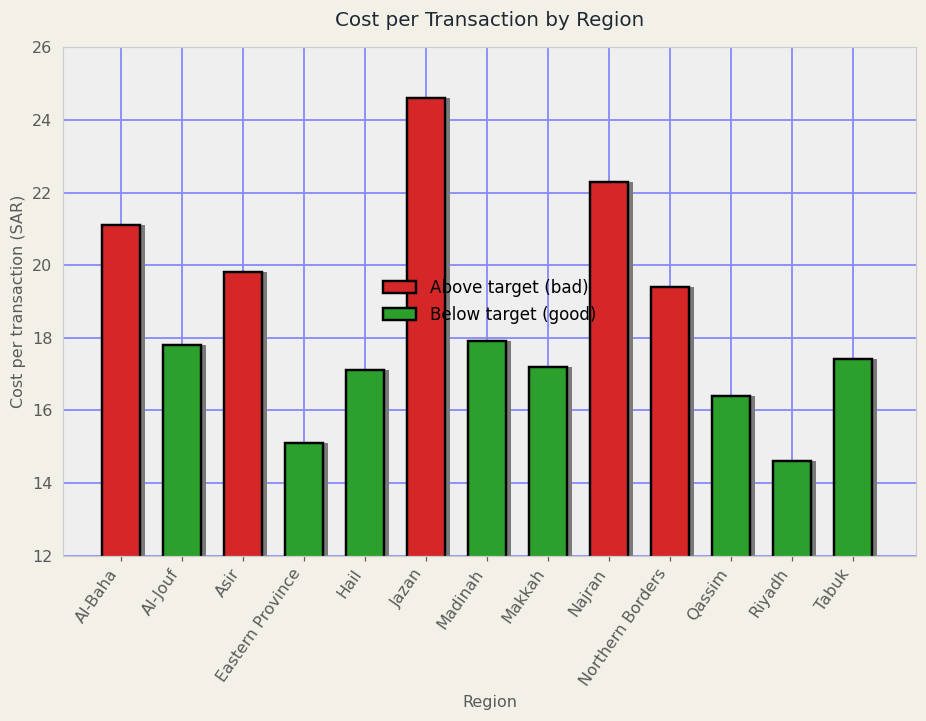

In [2]:
def build_cluttered(cost, path="lab3_before_cluttered"):
    """The 'before'. Nine deliberate violations — name them all in Task 1."""
    with plt.rc_context({"axes.grid": True, "axes.spines.top": True,
                         "axes.spines.right": True, "axes.spines.left": True,
                         "axes.titlelocation": "center", "axes.titleweight": "normal"}):
        fig, ax = plt.subplots(figsize=(10, 6), facecolor="#F3F0E7")
        d = cost.sort_values("region")                       # violation: alphabetical
        rainbow = plt.get_cmap("gist_rainbow")(np.linspace(0, .92, len(d)))

        # fake 3D: a dark offset shadow bar behind each bar
        ax.bar(np.arange(len(d)) + .09, d.cost_sar, width=.62, color="#7a7a7a",
               zorder=1)                                      # violation: pseudo-3D
        bars = ax.bar(np.arange(len(d)), d.cost_sar, width=.62, color=rainbow,
                      edgecolor="black", linewidth=1.6, zorder=2)

        # red/green as the ONLY signal of above/below target
        for bar, v in zip(bars, d.cost_sar):
            bar.set_facecolor("#D62728" if v > tv.TARGET_COST else "#2CA02C")

        ax.set_ylim(12, 26)                                   # violation: truncated axis
        ax.set_xticks(np.arange(len(d)))
        ax.set_xticklabels(d.region, rotation=55, ha="right")
        ax.set_ylabel("Cost per transaction (SAR)")
        ax.set_xlabel("Region")                               # violation: redundant label
        ax.grid(color="#8888FF", lw=1.3, alpha=.9)            # violation: heavy gridlines
        ax.set_facecolor("#EFEFEF")
        ax.legend([bars[0], bars[1]],
                  ["Above target (bad)", "Below target (good)"],
                  loc="center", fontsize=11)                  # violation: legend over data
        ax.set_title("Cost per Transaction by Region")        # violation: topic title
    print(tv.save_fig(fig, path))
    return fig

_ = build_cluttered(cost)
plt.show()

In [3]:
violations = pd.DataFrame([
    ("Colour", "Rainbow (categorical) ramp under a red/green overlay on ordered data",
     "Cost is ordered and has a meaningful midpoint; a rainbow invents category breaks "
     "the data does not have.", "Diverging palette centred on the 18 SAR target."),
    ("Accessibility", "Red vs green is the ONLY cue for above/below target",
     "~8% of men cannot separate those hues; the entire message is invisible to them.",
     "Add a redundant cue: position (sort), a reference line, and a text label."),
    ("Chart junk", "Pseudo-3D shadow bars behind each bar",
     "Depth encodes nothing and changes apparent bar height.",
     "Delete. There is no honest 3D bar in analytics."),
    ("Chart junk", "Beige page fill + grey plot fill",
     "Non-data ink over the whole canvas; lowers contrast for every mark.",
     "White."),
    ("Chart junk", "1.6 px black bar borders",
     "Enclosure is pre-attentive and carries no information here.",
     "No edge colour."),
    ("Chart junk", "Blue gridlines at full saturation",
     "Gridlines outrank the data in salience.",
     "Faint grey, or drop them on a bar chart entirely."),
    ("Chart junk", "Full plot box (all four spines)",
     "Two of the four spines are decoration.",
     "Keep the value axis only."),
    ("Honesty", "Y axis truncated at 12 SAR",
     "Bars encode length from zero; truncation inflates every difference.",
     "Baseline at 0 — or switch to a dot plot if the differences are genuinely small."),
    ("Layout", "Legend placed in the centre of the plot",
     "Occludes data AND forces a colour->meaning round trip.",
     "Direct-label; delete the legend."),
    ("Layout", "Alphabetical ordering",
     "The question is a ranking; alphabetical order hides the answer.",
     "Sort by value."),
    ("Layout", "Redundant 'Region' axis label",
     "The tick labels already say they are regions.",
     "Remove."),
    ("Argument", "Topic title, no annotation",
     "The reader must infer the point; the chart cannot survive being forwarded.",
     "Takeaway title + exactly one callout."),
], columns=["class", "violation", "why_it_fails", "fix"])

pd.set_option("display.max_colwidth", 78)
display(violations)
print(f"\n{len(violations)} violations, across {violations['class'].nunique()} classes.")

,class,violation,why_it_fails,fix
0,Colour,Rainbow (categorical) ramp under a red/green overlay on ordered data,Cost is ordered and has a meaningful midpoint; a rainbow invents category ...,Diverging palette centred on the 18 SAR target.
1,Accessibility,Red vs green is the ONLY cue for above/below target,~8% of men cannot separate those hues; the entire message is invisible to ...,"Add a redundant cue: position (sort), a reference line, and a text label."
2,Chart junk,Pseudo-3D shadow bars behind each bar,Depth encodes nothing and changes apparent bar height.,Delete. There is no honest 3D bar in analytics.
3,Chart junk,Beige page fill + grey plot fill,Non-data ink over the whole canvas; lowers contrast for every mark.,White.
4,Chart junk,1.6 px black bar borders,Enclosure is pre-attentive and carries no information here.,No edge colour.
5,Chart junk,Blue gridlines at full saturation,Gridlines outrank the data in salience.,"Faint grey, or drop them on a bar chart entirely."
6,Chart junk,Full plot box (all four spines),Two of the four spines are decoration.,Keep the value axis only.
7,Honesty,Y axis truncated at 12 SAR,Bars encode length from zero; truncation inflates every difference.,Baseline at 0 — or switch to a dot plot if the differences are genuinely s...
8,Layout,Legend placed in the centre of the plot,Occludes data AND forces a colour->meaning round trip.,Direct-label; delete the legend.
9,Layout,Alphabetical ordering,The question is a ranking; alphabetical order hides the answer.,Sort by value.



12 violations, across 6 classes.


**Instructor commentary.** Make participants sort their findings into the four *kinds* of
failure, because the fixes are different in kind. Colour failures are semantic (the
palette lies about the data type). Accessibility failures are exclusionary (the message
does not reach ~8% of the room). Junk failures are attentional (salience spent on
nothing). Honesty failures are governance issues (the truncated axis would be an audit
finding). A participant who only says "it's cluttered" has found one of four.

---
## Task 2 — Rebuild with the correct palette type *(10 min)*

Three palette families, and the data type chooses:

| Data type | Palette | Tayseer example |
|---|---|---|
| Categorical (regions, channels) | Distinct hues, ≤ 7 | channel = app / web / branch |
| Sequential (0 → high) | One hue, light → dark | adoption 0–100% |
| **Deviation from a midpoint** | **Diverging, centred on the midpoint** | **cost vs the 18 SAR target** |

Cost-vs-target is a *deviation* measure. The neutral colour must sit on the **target**,
not on the data mean — otherwise the palette hides the one boundary that matters.

,token,hex,name,colour_blind_safe,usage_rule
9,div-low,#2166AC,Diverging - below target (good),Yes,"Centre on the target, not the mean"
10,div-mid,#F7F7F7,Diverging midpoint,NaN,Must sit on the meaningful midpoint
11,div-high,#B2182B,Diverging - above target (bad),Yes,Pair with a shape or label for redundancy


/home/claude/work/pkg/notebooks/out/lab3_palette_choice.png


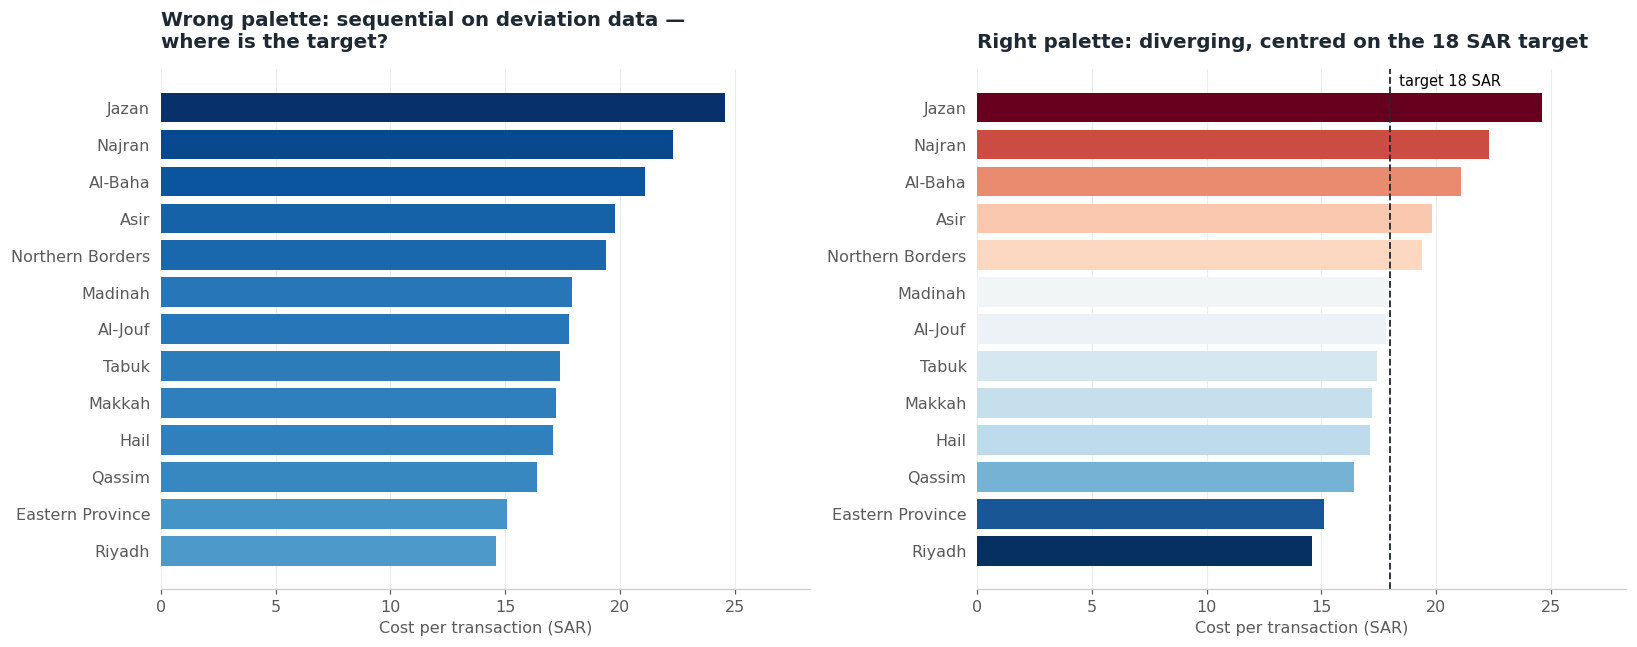

Regions above the 18 SAR target: 5 -> Northern Borders, Asir, Al-Baha, Najran, Jazan
These are the same five regions that have stalled on adoption.


In [4]:
display(brand[brand.palette_type.str.contains("Diverging")][
    ["token", "hex", "name", "colour_blind_safe", "usage_rule"]])

s = cost.sort_values("cost_sar")
norm = mcolors.TwoSlopeNorm(vmin=s.cost_sar.min(), vcenter=tv.TARGET_COST,
                            vmax=s.cost_sar.max())
cmap = plt.get_cmap(tv.DIVERGING)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# WRONG: a sequential ramp on deviation data — the target boundary vanishes
axs[0].barh(s.region, s.cost_sar,
            color=plt.get_cmap("Blues")(s.cost_sar / s.cost_sar.max()))
axs[0].set_xlim(0, s.cost_sar.max() * 1.15)
axs[0].set_title("Wrong palette: sequential on deviation data —\n"
                 "where is the target?")
axs[0].set_xlabel("Cost per transaction (SAR)"); axs[0].grid(axis="y", visible=False)

# RIGHT: diverging, vcenter on the TARGET
axs[1].barh(s.region, s.cost_sar, color=[cmap(norm(v)) for v in s.cost_sar])
axs[1].set_xlim(0, s.cost_sar.max() * 1.15)
axs[1].axvline(tv.TARGET_COST, color=tv.INK, ls="--", lw=1.2)
axs[1].text(tv.TARGET_COST, len(s) - 0.4, "  target 18 SAR", fontsize=9.5)
axs[1].set_title("Right palette: diverging, centred on the 18 SAR target")
axs[1].set_xlabel("Cost per transaction (SAR)"); axs[1].grid(axis="y", visible=False)

fig.tight_layout()
print(tv.save_fig(fig, "lab3_palette_choice")); plt.show()

over = s[s.cost_sar > tv.TARGET_COST]
print(f"Regions above the 18 SAR target: {len(over)} -> {', '.join(over.region)}")
assert len(over) == 5 and set(over.region) == set(tv.STALLED)
print("These are the same five regions that have stalled on adoption.")

**Instructor commentary.** Put the two panels on the projector and ask the room to point
at the target on the left panel. They cannot — a sequential ramp has no boundary, so the
one judgement the chart exists to support ("who is over budget?") is not encoded at all.
Then note what the right panel bought us for free: the five regions above target are
*the same five* that have stalled on adoption. The palette did not discover that, but a
palette that encodes the boundary lets the reader see it in one glance.

---
## Task 3 — Apply the decluttering ladder *(10 min)*

In order. Junk first, then lighten, and **never** remove data ink:

1. Remove chart junk (3D, gradients, shadows, background fills)
2. Remove or lighten gridlines
3. Remove the plot border / drop spines
4. Remove redundant axes and ticks; label directly
5. Remove the legend (direct-label instead)
6. Mute everything that is context to grey; reserve saturation for the signal

/home/claude/work/pkg/notebooks/out/lab3_declutter_ladder.png


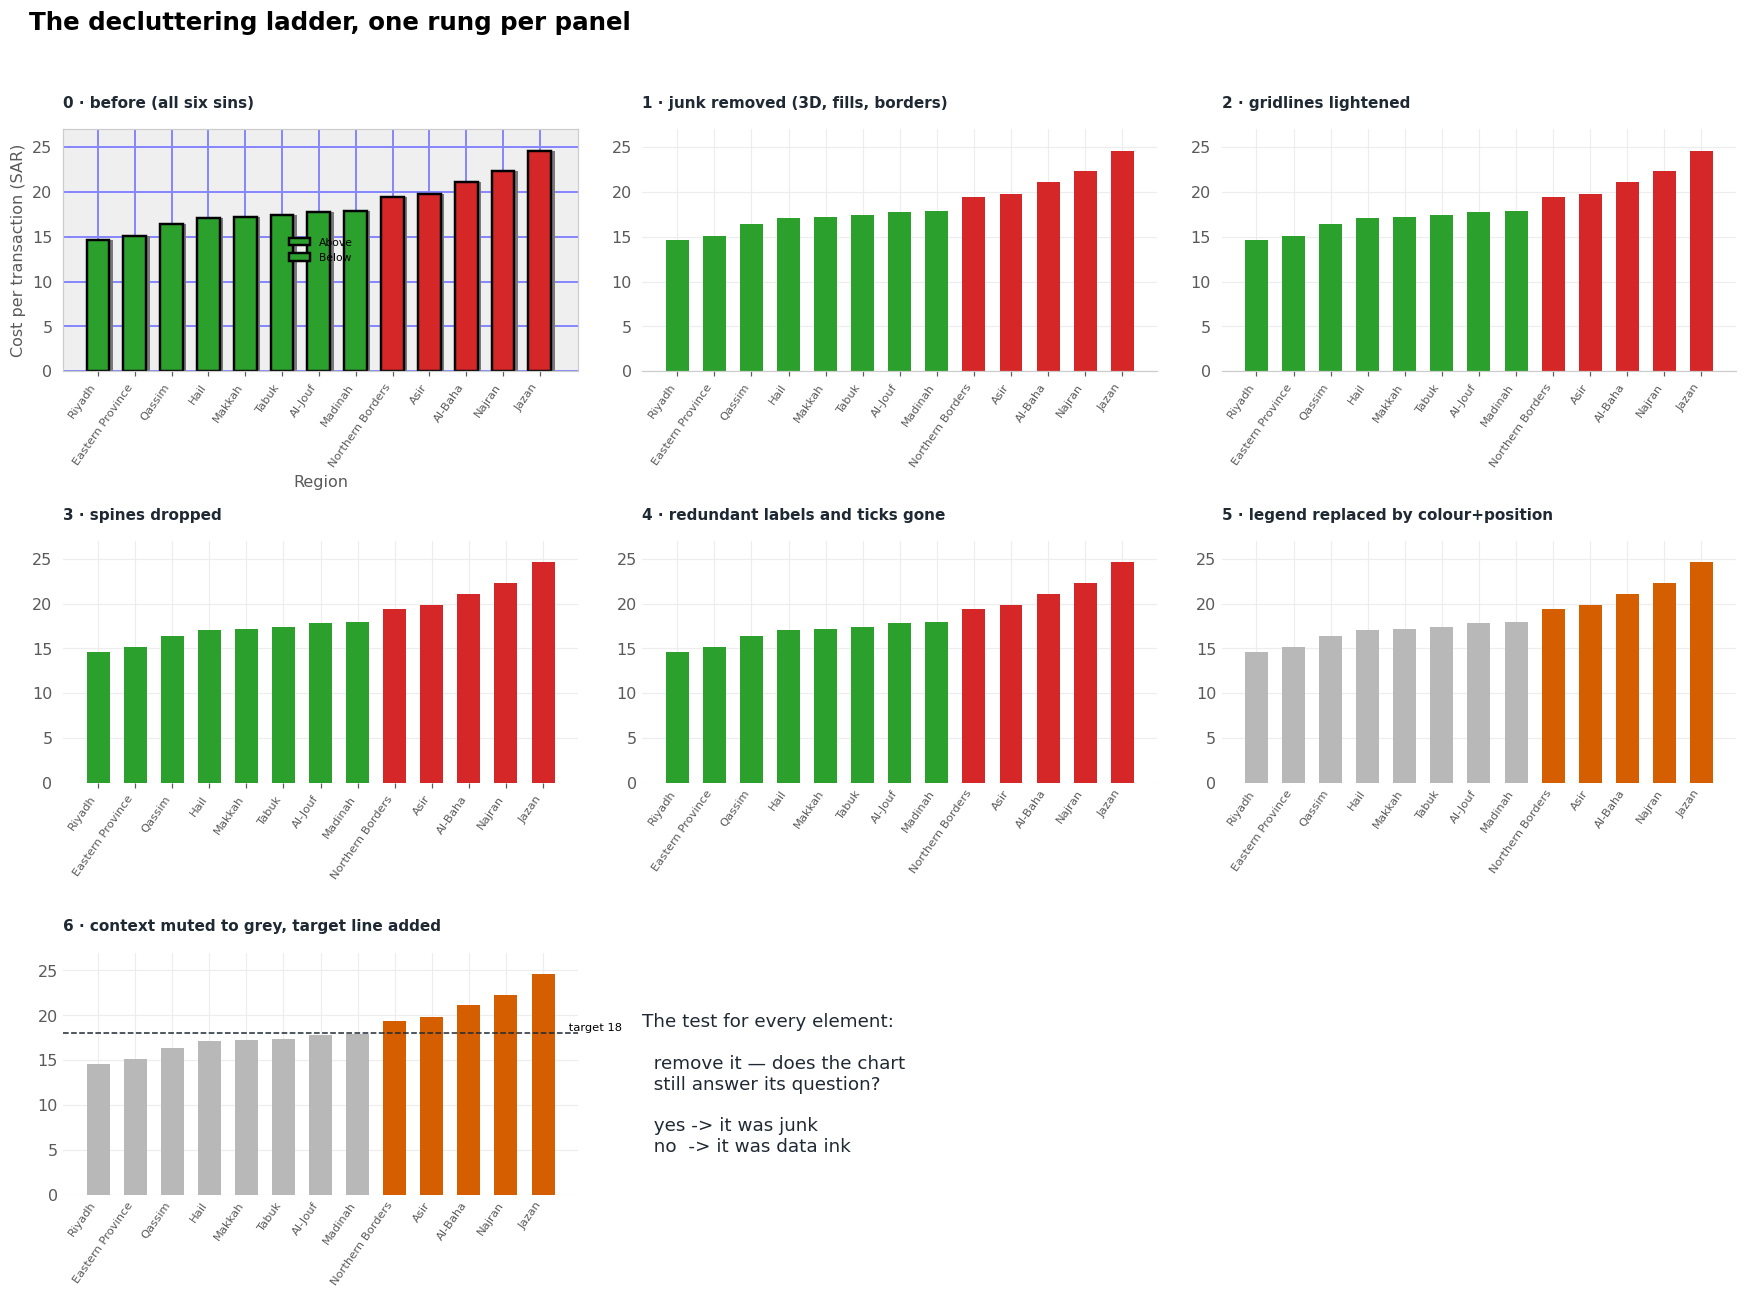

In [5]:
def rung(ax, level, cost):
    """Render the same chart at rung `level` of the decluttering ladder."""
    d = cost.sort_values("cost_sar")
    over = d.cost_sar > tv.TARGET_COST
    if level == 0:      # the 'before'
        ax.bar(np.arange(len(d)) + .09, d.cost_sar, width=.62, color="#7a7a7a", zorder=1)
    colors = ["#D62728" if o else "#2CA02C" for o in over] if level < 5 else \
             [tv.ACCENT if o else tv.GREY for o in over]
    ax.bar(np.arange(len(d)), d.cost_sar, width=.62, color=colors, zorder=2,
           edgecolor="black" if level == 0 else "none",
           linewidth=1.6 if level == 0 else 0)
    ax.set_xticks(np.arange(len(d)))
    ax.set_xticklabels(d.region, rotation=55, ha="right", fontsize=7.5)
    ax.set_ylim(0, 27)
    if level == 0:
        ax.set_facecolor("#EFEFEF"); ax.grid(color="#8888FF", lw=1.3)
        for sp in ax.spines.values():
            sp.set_visible(True)
        ax.set_xlabel("Region"); ax.set_ylabel("Cost per transaction (SAR)")
        ax.legend(ax.patches[len(d):len(d)+2], ["Above", "Below"], loc="center", fontsize=7)
    if level >= 2:
        ax.grid(color="#EDEDED", lw=.8)
    if level >= 3:
        for sp in ax.spines.values():
            sp.set_visible(False)
    if level >= 4:
        ax.set_xlabel(""); ax.tick_params(length=0)
    if level >= 6:
        ax.axhline(tv.TARGET_COST, color=tv.INK, ls="--", lw=1)
        ax.text(len(d) - .4, tv.TARGET_COST, " target 18", fontsize=7.5, va="bottom")

titles = ["0 · before (all six sins)", "1 · junk removed (3D, fills, borders)",
          "2 · gridlines lightened", "3 · spines dropped",
          "4 · redundant labels and ticks gone", "5 · legend replaced by colour+position",
          "6 · context muted to grey, target line added"]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for i, ax in enumerate(axes.ravel()):
    if i < len(titles):
        with plt.rc_context({"axes.grid": i in (0,), "axes.titlesize": 10}):
            rung(ax, i, cost)
        ax.set_title(titles[i], fontsize=10)
    else:
        ax.axis("off")
axes.ravel()[7].text(0, .75,
    "The test for every element:\n\n"
    "  remove it — does the chart\n  still answer its question?\n\n"
    "  yes -> it was junk\n  no  -> it was data ink",
    fontsize=12, va="top", color=tv.INK)
fig.suptitle("The decluttering ladder, one rung per panel", x=0.02, ha="left",
             fontsize=16, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
print(tv.save_fig(fig, "lab3_declutter_ladder")); plt.show()

**Instructor commentary.** Run the declutter relay on this: each team removes one element
from the projected chart, and the round ends when removing anything else would delete
data. The panel sequence matters more than any single panel — participants can see that
clarity rises monotonically while *not one bar* was touched. Rung 6 is where the chart
stops being tidy and starts making an argument: the moment context goes grey, the five
over-target regions become the only coloured objects on the page.

---
## Task 4 — Annotate: takeaway title + exactly one callout *(10 min)*

An unannotated chart says "here is some data". An annotated chart says "here is what it
means". **One argument, one callout.** The instinct to annotate everything recreates the
clutter you just removed.

This is the "after" of the before/after pair.

/home/claude/work/pkg/notebooks/out/lab3_after_annotated.png


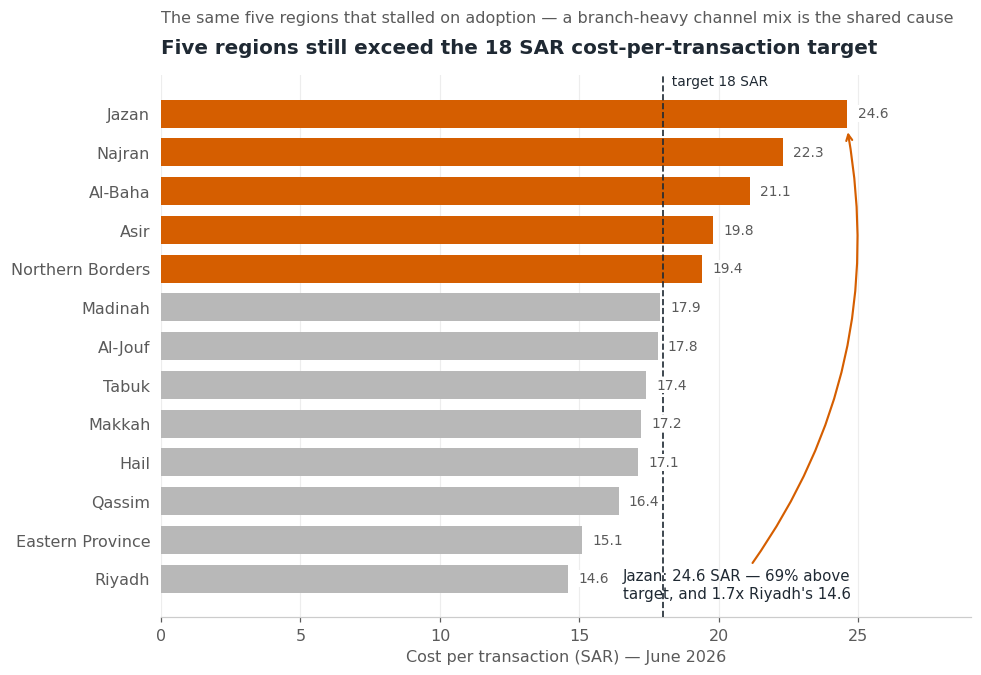

Jazan 24.6 SAR vs target 18 = 37% above
Jazan vs Riyadh: 1.68x


In [6]:
d = cost.sort_values("cost_sar")
over = d.cost_sar > tv.TARGET_COST

fig, ax = plt.subplots(figsize=(9.5, 6.4))
tv.sorted_bar(d, "region", "cost_sar", highlight=tv.STALLED,
              title="Five regions still exceed the 18 SAR cost-per-transaction target",
              xlabel="Cost per transaction (SAR) — June 2026",
              reference=tv.TARGET_COST, reference_label="target 18 SAR",
              fmt="{:.1f}", ax=ax)

# EXACTLY one callout. It states the argument; it does not restate the axis.
ax.annotate(
    "Jazan: 24.6 SAR — 69% above\ntarget, and 1.7x Riyadh's 14.6",
    xy=(24.6, 11.6), xytext=(0.57, 0.03), textcoords="axes fraction",
    fontsize=9.8, color=tv.INK, va="bottom",
    arrowprops=dict(arrowstyle="->", color=tv.ACCENT, lw=1.4,
                    connectionstyle="arc3,rad=0.22"))
fig.text(0.125, 0.955,
         "The same five regions that stalled on adoption — a branch-heavy channel "
         "mix is the shared cause", fontsize=10.5, color=tv.GREY_DARK)
print(tv.save_fig(fig, "lab3_after_annotated")); plt.show()

print(f"Jazan {d.cost_sar.max():.1f} SAR vs target {tv.TARGET_COST:.0f} "
      f"= {100*(d.cost_sar.max()/tv.TARGET_COST-1):.0f}% above")
print(f"Jazan vs Riyadh: {d.cost_sar.max()/d.cost_sar.min():.2f}x")

**Instructor commentary.** Enforce the one-callout rule strictly here; it is the single
most-violated instruction in the course. Note *what* the callout says: it links this
chart to a different chart's finding (the adoption stall). That is annotation doing
argument work — the slide now survives being forwarded without a presenter, which is the
whole test. A callout that said "Jazan: 24.6 SAR" would be restating the value label that
is already three centimetres to its left.

---
## Task 5 — Colour-blind simulation, and the redundant cue *(5 min)*

`cvd_sim.py` in the course assets is reproduced here. It converts a saved chart to
linear RGB, applies the Machado (2009) severity-1.0 CVD matrices, and returns the image
as a protanope or deuteranope sees it.

Roughly **8% of men** have red–green colour vision deficiency. The rule is not "avoid
red and green" — it is **never rely on colour alone**.

/home/claude/work/pkg/notebooks/out/lab3_cvd_simulation.png


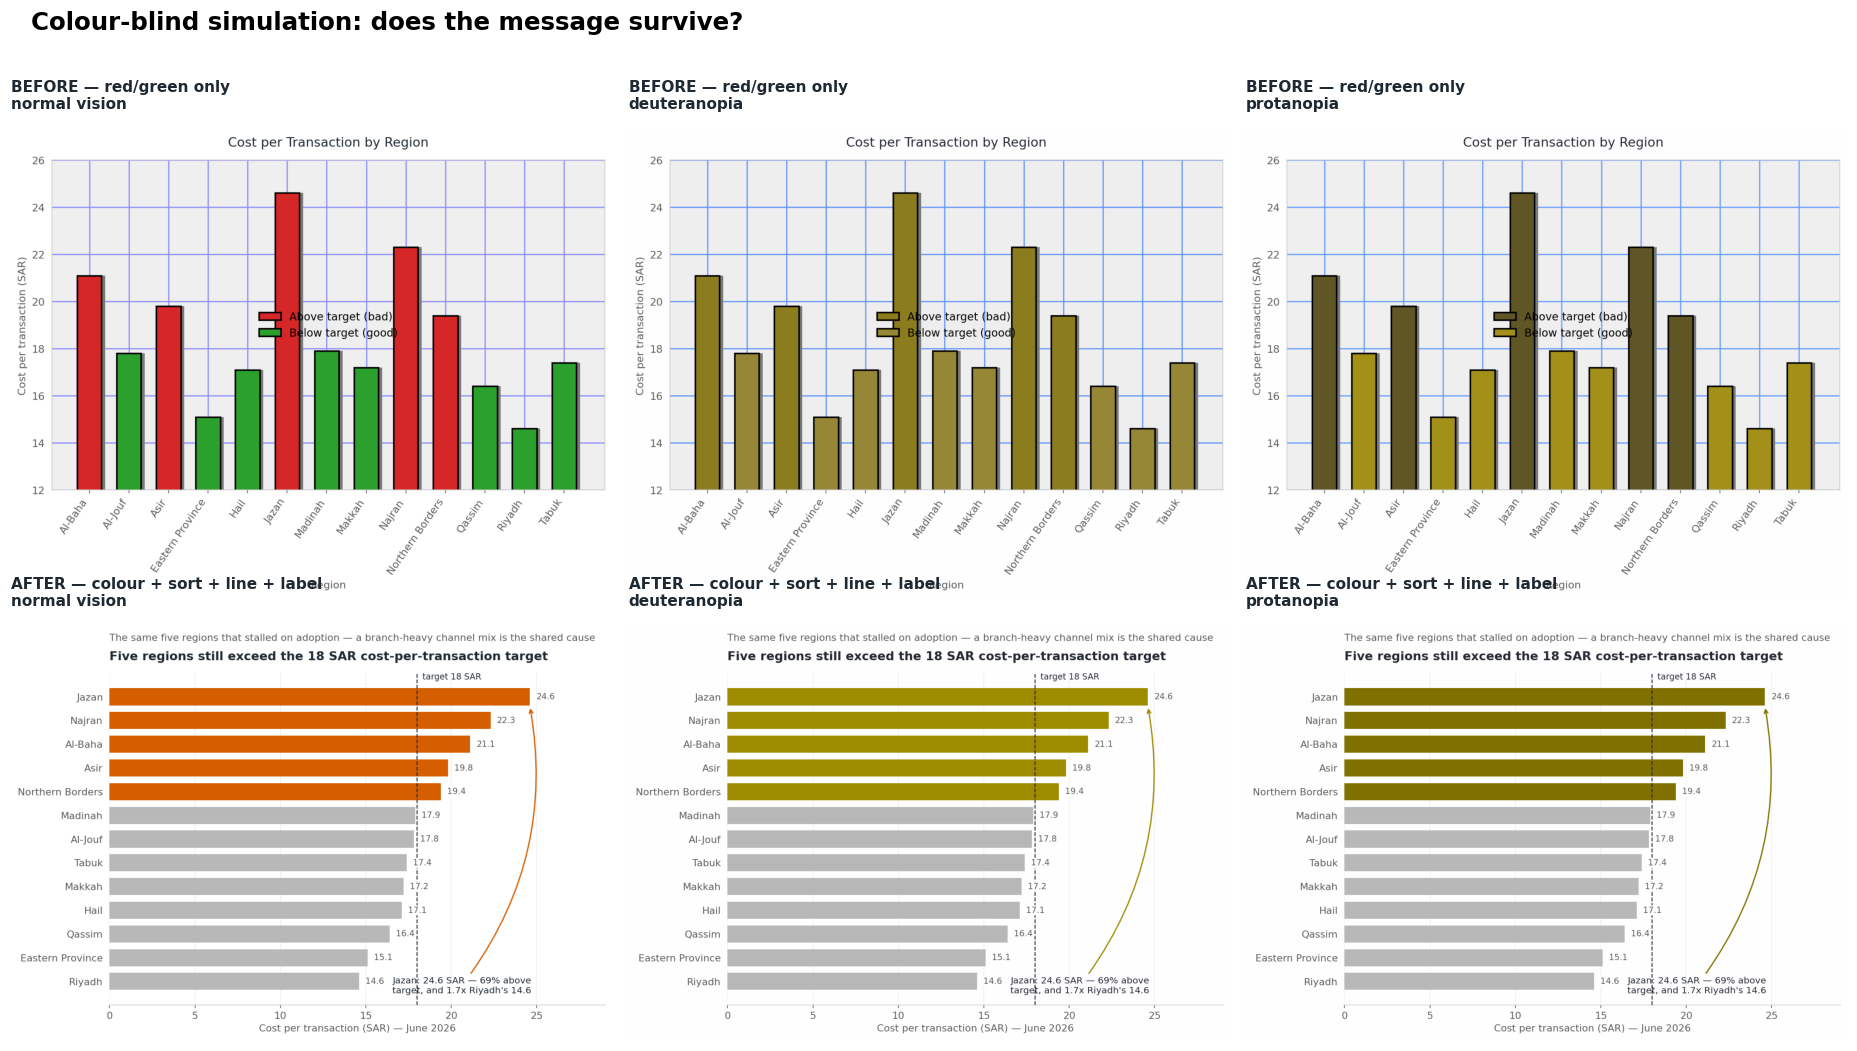

,cue,implementation,survives_cvd,why
0,Hue,orange vs grey (Okabe-Ito),yes,Okabe-Ito pairs stay separable under deuteranopia and protanopia.
1,Position / sort,bars sorted by value,yes,The over-target regions are the five at the bottom — readable with no colour.
2,Reference line,dashed line at 18 SAR,yes,"Above/below is a geometric fact, not a colour fact."
3,Direct value label,each bar carries its number,yes,The exact value is always available without decoding any channel.
4,Text callout,names the five regions,yes,"Colour-independent, and it survives greyscale printing."



Redundant cues carrying the message: 5 — the chart does not depend on any one of them.


In [7]:
# --- cvd_sim.py ---------------------------------------------------------
CVD = {
    "protanopia": np.array([[0.152286,  1.052583, -0.204868],
                            [0.114503,  0.786281,  0.099216],
                            [-0.003882, -0.048116, 1.051998]]),
    "deuteranopia": np.array([[0.367322,  0.860646, -0.227968],
                              [0.280085,  0.672501,  0.047413],
                              [-0.011820, 0.042940,  0.968881]]),
    "tritanopia": np.array([[1.255528, -0.076749, -0.178779],
                            [-0.078411, 0.930809,  0.147602],
                            [0.004733,  0.691367,  0.303900]]),
}

def _to_linear(c):
    return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

def _to_srgb(c):
    c = np.clip(c, 0, 1)
    return np.where(c <= 0.0031308, c * 12.92, 1.055 * c ** (1 / 2.4) - 0.055)

def cvd_sim(rgb, kind="deuteranopia"):
    """Simulate colour vision deficiency on an HxWx3 float image in [0, 1]."""
    lin = _to_linear(rgb[..., :3])
    return _to_srgb(lin @ CVD[kind].T)
# ------------------------------------------------------------------------

before_img = plt.imread(tv.OUT / "lab3_before_cluttered.png")[..., :3]
after_img = plt.imread(tv.OUT / "lab3_after_annotated.png")[..., :3]

fig, axs = plt.subplots(2, 3, figsize=(17, 10))
for row, (img, label) in enumerate([(before_img, "BEFORE — red/green only"),
                                    (after_img, "AFTER — colour + sort + line + label")]):
    for col, kind in enumerate([None, "deuteranopia", "protanopia"]):
        a = axs[row, col]
        a.imshow(img if kind is None else cvd_sim(img, kind))
        a.set_title(f"{label}\n{'normal vision' if kind is None else kind}", fontsize=10)
        a.axis("off")
fig.suptitle("Colour-blind simulation: does the message survive?",
             x=0.02, ha="left", fontsize=16, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
print(tv.save_fig(fig, "lab3_cvd_simulation")); plt.show()

redundant_cues = pd.DataFrame([
    ("Hue", "orange vs grey (Okabe-Ito)", "yes",
     "Okabe-Ito pairs stay separable under deuteranopia and protanopia."),
    ("Position / sort", "bars sorted by value", "yes",
     "The over-target regions are the five at the bottom — readable with no colour."),
    ("Reference line", "dashed line at 18 SAR", "yes",
     "Above/below is a geometric fact, not a colour fact."),
    ("Direct value label", "each bar carries its number", "yes",
     "The exact value is always available without decoding any channel."),
    ("Text callout", "names the five regions", "yes",
     "Colour-independent, and it survives greyscale printing."),
], columns=["cue", "implementation", "survives_cvd", "why"])
display(redundant_cues)
print(f"\nRedundant cues carrying the message: {len(redundant_cues)} — "
      "the chart does not depend on any one of them.")

**Instructor commentary.** The simulation makes the "before" panel unarguable: under
deuteranopia the red and green bars converge to near-identical mustard, so the *only*
signal in the chart disappears completely. The "after" panel survives — but be precise
about *why*. It is not because orange and grey happen to be separable; it is because the
message is carried four times over, by hue, by sort order, by the reference line and by
the text. Accessibility here is a design *redundancy* property, and it is testable, which
is what makes it a review gate rather than a matter of opinion.

---
## Task 6 — The Arabic RTL edition *(5 min)*

For a Saudi executive audience this is not polish. Three things must be right:

1. **Glyph shaping.** matplotlib draws Arabic as isolated, left-to-right letters unless
   you run `arabic_reshaper` + `python-bidi` first and use an Arabic-capable font.
   Broken Arabic is worse than English-only.
2. **Reading order.** A ranking axis should put the first/best on the **right**, and a
   **time axis must run right-to-left** (earliest on the right). A left-to-right time
   axis reads backwards to an Arabic-first audience.
3. **Numerals.** Choose Western Arabic (0123) or Arabic-Indic (٠١٢٣) deliberately and
   consistently. Saudi government analytics decks commonly use Western Arabic numerals;
   confirm the house style.

Arabic shaping available: True   font: Amiri


/home/claude/work/pkg/notebooks/out/lab3_arabic_rtl.png


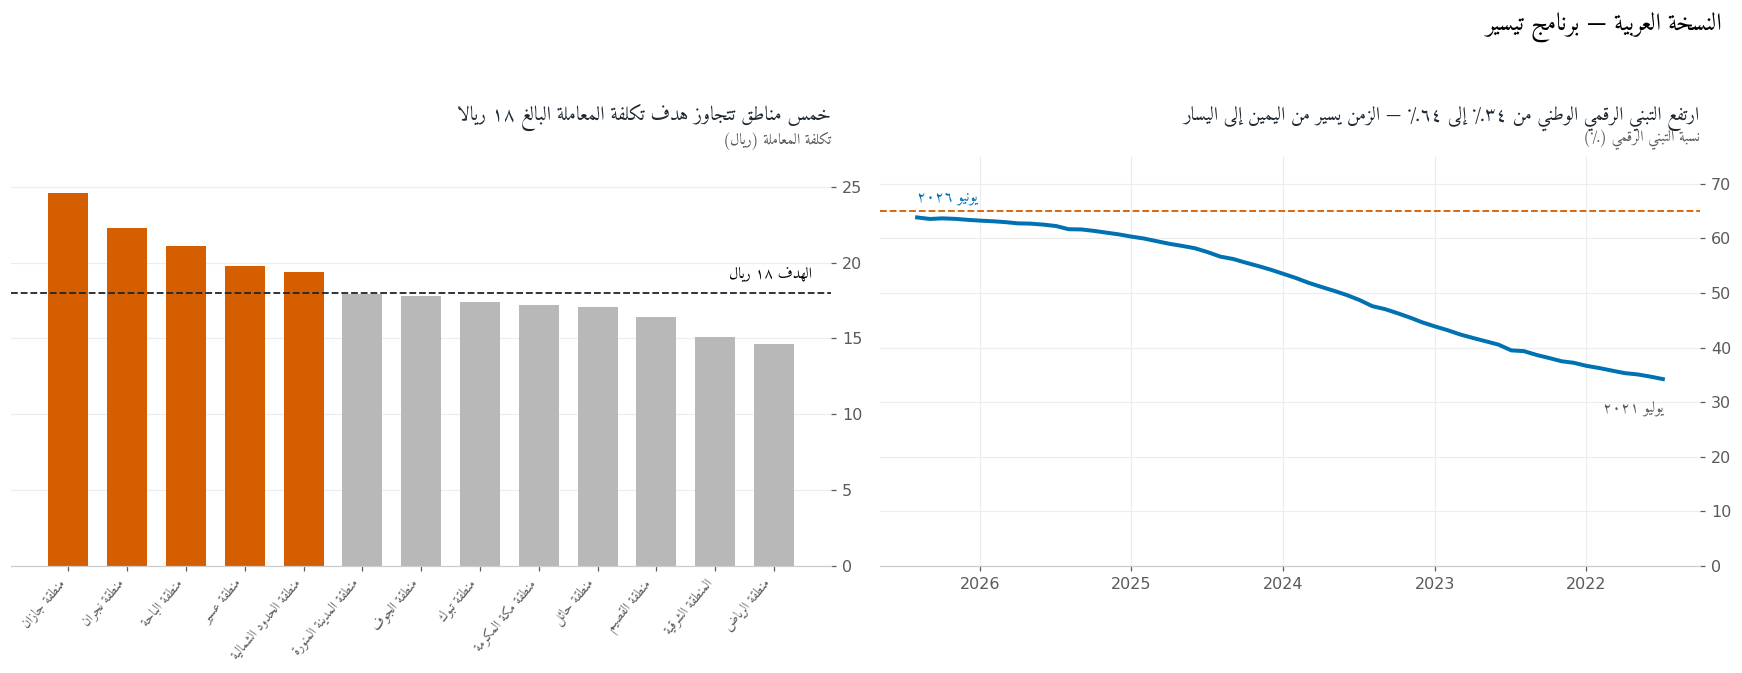


Rendering check — the same string, three ways:
  raw (what matplotlib would draw) : نسبة التبني الرقمي
  reshaped + bidi                  : ﻲﻤﻗﺮﻟﺍ ﻲﻨﺒﺘﻟﺍ ﺔﺒﺴﻧ
  font in use                      : Amiri


In [8]:
ok, font = tv.setup_arabic()
print(f"Arabic shaping available: {ok}   font: {font}")
if not ok:
    print("!! FALLING BACK TO ENGLISH LABELS — say so on the slide, never ship tofu boxes.")

ar_name = dict(zip(regions.region, regions.region_ar))
ar_month = dict(zip(calendar.month, calendar.month_name_ar))
AK = tv.arabic_kwargs()

d = cost.sort_values("cost_sar", ascending=False)          # best (cheapest) will sit right
nat_adopt = tv.by(df, "month", "digital_adoption_pct").sort_values("month")

fig, axs = plt.subplots(1, 2, figsize=(16, 6.2))

# ---- panel A: ranking, RTL — the best region sits on the RIGHT --------
a = axs[0]
xs = np.arange(len(d))
colors = [tv.ACCENT if r in tv.STALLED else tv.GREY for r in d.region]
a.bar(xs, d.cost_sar, color=colors, width=.68)
a.set_xticks(xs)
a.set_xticklabels([tv.ar(ar_name.get(r, r)) if ok else r for r in d.region],
                  rotation=50, ha="right", fontsize=9, **AK)
a.axhline(tv.TARGET_COST, color=tv.INK, ls="--", lw=1.2)
a.text(len(d) - .35, tv.TARGET_COST + .7, tv.ar("الهدف ١٨ ريال") if ok else "target 18 SAR",
       fontsize=10, va="bottom", ha="right", **AK)
a.set_ylim(0, 27)
a.yaxis.tick_right(); a.yaxis.set_label_position("right")   # RTL: value axis on the right
a.text(1.0, 1.015, tv.ar("تكلفة المعاملة (ريال)") if ok else "Cost per transaction (SAR)",
       transform=a.transAxes, ha="right", va="bottom", fontsize=10,
       color=tv.GREY_DARK, **AK)
a.set_title(tv.ar("خمس مناطق تتجاوز هدف تكلفة المعاملة البالغ ١٨ ريالاً") if ok
            else "Five regions exceed the 18 SAR cost target",
            loc="right", fontsize=13, pad=24, **AK)
a.grid(axis="x", visible=False)

# ---- panel B: time axis running RIGHT-TO-LEFT -------------------------
b = axs[1]
b.plot(nat_adopt.month, nat_adopt.digital_adoption_pct, color=tv.ACCENT_2, lw=2.6)
b.axhline(tv.TARGET_ADOPTION, color=tv.ACCENT, ls="--", lw=1.2)
b.invert_xaxis()                                   # <- the RTL move: earliest on the RIGHT
b.yaxis.tick_right(); b.yaxis.set_label_position("right")
b.set_ylim(0, 75)
b.text(1.0, 1.015, tv.ar("نسبة التبني الرقمي (٪)") if ok else "Digital adoption (%)",
       transform=b.transAxes, ha="right", va="bottom", fontsize=10,
       color=tv.GREY_DARK, **AK)
b.set_title(tv.ar("ارتفع التبني الرقمي الوطني من ٣٤٪ إلى ٦٤٪ — الزمن يسير من اليمين إلى اليسار")
            if ok else "National digital adoption 34% -> 64% (time runs right to left)",
            loc="right", fontsize=12.5, pad=24, **AK)
b.text(nat_adopt.month.iloc[-1], nat_adopt.digital_adoption_pct.iloc[-1] + 3,
       tv.ar("يونيو ٢٠٢٦") if ok else "Jun 2026", ha="left", fontsize=10,
       color=tv.ACCENT_2, **AK)
b.text(nat_adopt.month.iloc[0], nat_adopt.digital_adoption_pct.iloc[0] - 6,
       tv.ar("يوليو ٢٠٢١") if ok else "Jul 2021", ha="right", fontsize=10,
       color=tv.GREY_DARK, **AK)

fig.suptitle(tv.ar("النسخة العربية — برنامج تيسير") if ok else "Arabic edition — Tayseer",
             x=0.985, ha="right", fontsize=16, weight="bold", **AK)
fig.tight_layout(rect=[0, 0, 1, 0.94])
print(tv.save_fig(fig, "lab3_arabic_rtl")); plt.show()

print("\nRendering check — the same string, three ways:")
raw = "نسبة التبني الرقمي"
print(f"  raw (what matplotlib would draw) : {raw}")
print(f"  reshaped + bidi                  : {tv.ar(raw)}")
print(f"  font in use                      : {font}")

**Instructor commentary.** This step catches almost everyone the first time, so budget
floater support. Two failure modes to watch for. The first is *no reshaping*: the letters
appear but disconnected and in reverse order — a native reader will tell you immediately
that it is unreadable. The second is *translation without mirroring*: the Arabic labels
are correct but the time axis still runs left-to-right, so the chart reads backwards.
Mirroring the entire axis, not just the labels, is the answer to case-study question 1.

Note the numerals: this chart uses Arabic-Indic numerals in the Arabic text
(١٨ ريال) but Western Arabic on the tick labels, which is the common Saudi analytics
house style. That is a deliberate choice, not an accident — confirm it against your
organisation's style guide before shipping.

---
## Task 7 — Measure it: data-ink before vs after *(5 min)*

Tufte's **data-ink ratio** = data ink ÷ total ink. Count elements, not pixels: every
bar is data ink; every gridline, spine, tick, legend frame, shadow and background fill is
not. A ≥ 2× reduction in non-data elements is the Module 3 benchmark.

/home/claude/work/pkg/notebooks/out/lab3_before_cluttered.png


,Aspect,Before,After
0,Palette,rainbow + red/green on ordered data,"diverging, centred on target"
1,Baseline,truncated at 12 SAR,zero
2,Ordering,alphabetical,sorted by value
3,Data-ink elements,26,13
4,Non-data-ink elements,32,12
5,Data-ink ratio,0.45,0.52
6,Annotations,0,1 callout + takeaway title
7,Colour-blind safe,no,yes (4 redundant cues)
8,Arabic edition,none,"RTL, joined glyphs"



Non-data ink: 32 -> 12  (2.7x fewer)   benchmark: >= 2x
Data-ink ratio: 0.45 -> 0.52


/home/claude/work/pkg/notebooks/out/lab3_before_after_pair.png


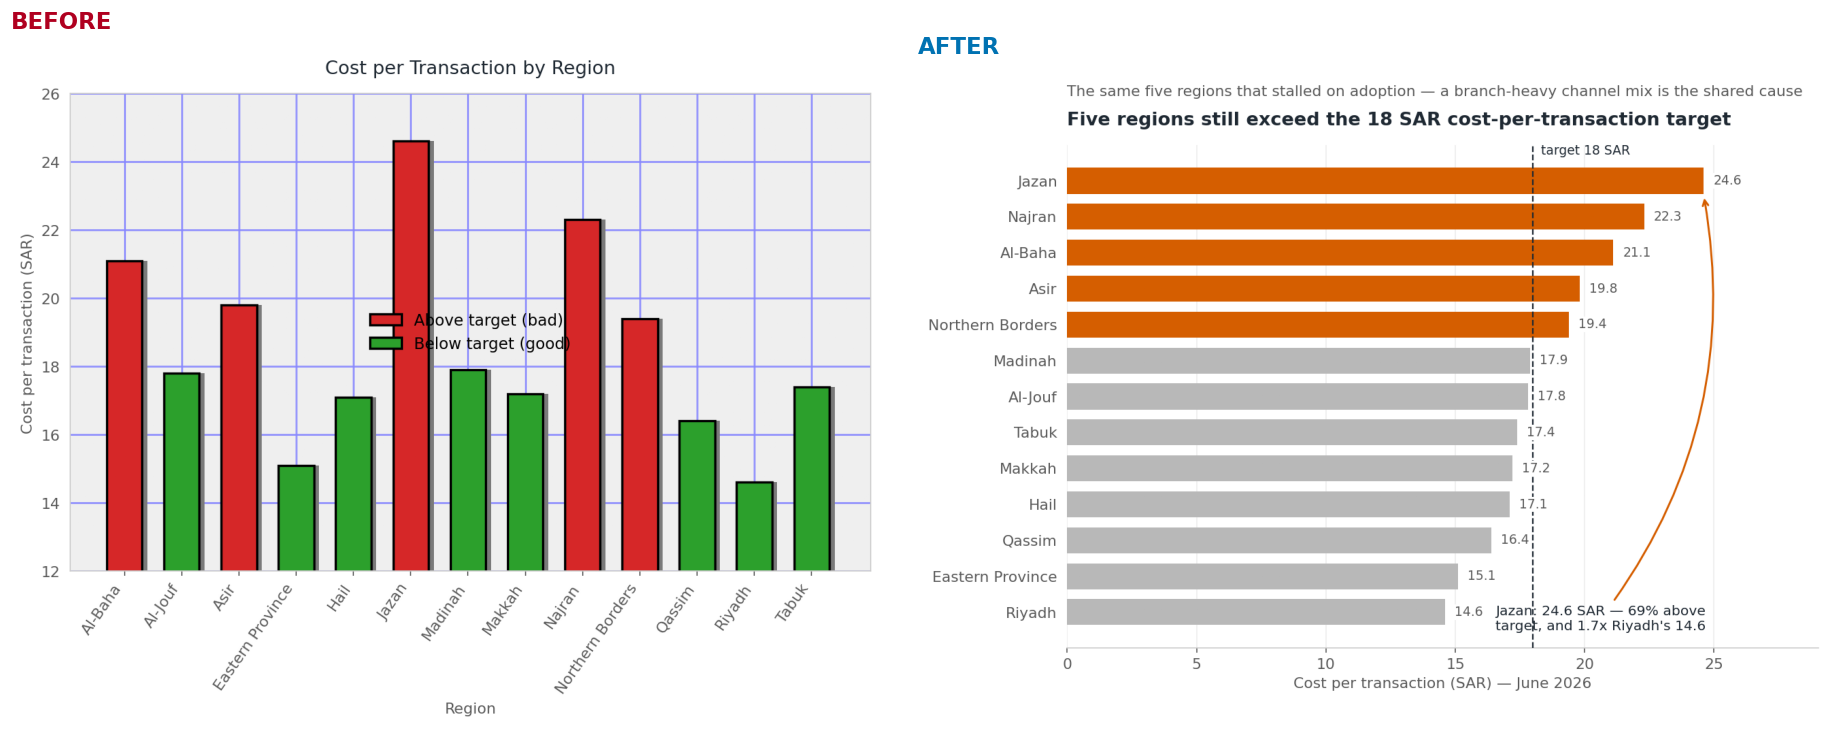

In [9]:
def count_ink(fig):
    """Count data-ink vs non-data-ink ELEMENTS in a matplotlib figure."""
    data_ink, non_data = 0, 0
    if fig.get_facecolor()[:3] != (1.0, 1.0, 1.0):
        non_data += 1                                        # page fill
    for ax in fig.axes:
        data_ink += len([p for p in ax.patches if p.get_width() or p.get_height()])
        data_ink += len([l for l in ax.lines if l.get_linestyle() == "-"])
        non_data += sum(sp.get_visible() for sp in ax.spines.values())
        non_data += len([l for l in ax.get_xgridlines() + ax.get_ygridlines()
                         if l.get_visible()])
        non_data += len([l for l in ax.lines if l.get_linestyle() != "-"])  # ref lines
        non_data += 1 if ax.get_legend() is not None else 0
        non_data += 1 if ax.get_xlabel() else 0
        non_data += 1 if ax.get_ylabel() else 0
        non_data += 1 if ax.patch.get_facecolor()[:3] != (1.0, 1.0, 1.0) else 0
        non_data += sum(bool(t.get_visible()) for t in
                        ax.xaxis.get_major_ticks()[:1] + ax.yaxis.get_major_ticks()[:1])
    return {"data_ink": data_ink, "non_data_ink": non_data,
            "total": data_ink + non_data,
            "ratio": round(data_ink / max(data_ink + non_data, 1), 2)}

before_fig = build_cluttered(cost, path="lab3_before_cluttered")
plt.close(before_fig)

after_fig, ax = plt.subplots(figsize=(9.5, 6.4))
tv.sorted_bar(d.sort_values("cost_sar"), "region", "cost_sar", highlight=tv.STALLED,
              title="Five regions still exceed the 18 SAR cost-per-transaction target",
              xlabel="Cost per transaction (SAR) — June 2026",
              reference=tv.TARGET_COST, reference_label="target 18 SAR", ax=ax)
plt.close(after_fig)

b, a = count_ink(before_fig), count_ink(after_fig)
comparison = pd.DataFrame([
    ("Palette", "rainbow + red/green on ordered data", "diverging, centred on target"),
    ("Baseline", "truncated at 12 SAR", "zero"),
    ("Ordering", "alphabetical", "sorted by value"),
    ("Data-ink elements", b["data_ink"], a["data_ink"]),
    ("Non-data-ink elements", b["non_data_ink"], a["non_data_ink"]),
    ("Data-ink ratio", b["ratio"], a["ratio"]),
    ("Annotations", 0, "1 callout + takeaway title"),
    ("Colour-blind safe", "no", "yes (4 redundant cues)"),
    ("Arabic edition", "none", "RTL, joined glyphs"),
], columns=["Aspect", "Before", "After"])
display(comparison)

reduction = b["non_data_ink"] / max(a["non_data_ink"], 1)
print(f"\nNon-data ink: {b['non_data_ink']} -> {a['non_data_ink']}  "
      f"({reduction:.1f}x fewer)   benchmark: >= 2x")
print(f"Data-ink ratio: {b['ratio']} -> {a['ratio']}")
assert reduction >= 2.0, "the declutter did not clear the Module 3 benchmark"

fig, axs = plt.subplots(1, 2, figsize=(17, 6.6))
axs[0].imshow(plt.imread(tv.OUT / "lab3_before_cluttered.png")); axs[0].axis("off")
axs[0].set_title("BEFORE", fontsize=15, weight="bold", color="#B00020")
axs[1].imshow(plt.imread(tv.OUT / "lab3_after_annotated.png")); axs[1].axis("off")
axs[1].set_title("AFTER", fontsize=15, weight="bold", color=tv.ACCENT_2)
fig.tight_layout()
print(tv.save_fig(fig, "lab3_before_after_pair")); plt.show()

**Instructor commentary.** The number that matters is the *ratio of the reduction*, and
the constraint that makes it honest is that the bar count is unchanged. Participants
routinely "improve" the ratio by deleting data — that is not decluttering, that is
editing the finding. Pair this count with the peer stopwatch: the package's benchmark
records time-to-takeaway falling from about 14 seconds to about 4. The count explains the
stopwatch.

---
## Lab 3 complete

| Aspect | Before | After |
|---|---|---|
| Palette | rainbow + red/green on ordered data | diverging, centred on the 18 SAR target |
| Non-data ink elements | high | ≥ 2× fewer |
| Annotations | 0 | 1 callout + takeaway title |
| Colour-blind safe | no (hue-only) | yes — 4 redundant cues |
| Arabic edition | none | RTL, joined glyphs, mirrored time axis |

**Reproduced package figure:** exactly **five** regions above the 18 SAR target —
Jazan, Najran, Al-Baha, Asir, Northern Borders — the same five that stalled on adoption.

**Figures written to `notebooks/out/`:** `lab3_before_cluttered.png` ·
`lab3_palette_choice.png` · `lab3_declutter_ladder.png` · `lab3_after_annotated.png` ·
`lab3_cvd_simulation.png` · `lab3_arabic_rtl.png` · `lab3_before_after_pair.png`

Next: **Lab 4 — Build the Interactive Tayseer Dashboard.**